---
title: Quantum mechanics basics
description: An overview of the quantum mechanical principles relevant to quantum computing.
---

{/* cspell:ignore mdash */}



# Quantum mechanics basics

## Introduction

In the following video, Olivia Lanes steps you through the content in this lesson. Alternatively, you can open the [YouTube video](https://youtu.be/lKFElrwEZrU?si=jdygTwHALqlrJAez) for this lesson in a separate window.

<IBMVideo id="134778627" title="In this video Olivia reviews the fundamental quantum physics and math necessary for your quantum computing journey." />

In the previous lesson, we learned how to produce an entangled state of two qubits, known as a "Bell state." When we measured the state, we saw that the measurements of the two qubits were *correlated*: when one was measured to be `0` then the other was also measured `0` and when one was `1` the other was measured `1`, too. We saw that this is a hallmark of quantum entanglement. Today we'll dig deeper into this state and what it reveals about the quantum physics fundamental to quantum computing.

## The Bell state

Many of the quantum phenomena that make quantum computers behave differently from classical computers are already present in the deceptively simple Bell state we produced in the previous lesson. Let's bring back that Bell state circuit:



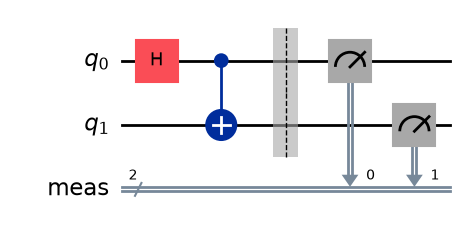

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
qc.draw("mpl")

The image above represents the quantum circuit for making the Bell state $\vert\Phi^+\rangle$. The two black horizontal lines represent our two qubits, and the boxes and other symbols on those lines represent gates or operations performed on the corresponding qubits. The gray double line is a classical information bus that allows us to store the classical information that we obtain by measuring the two qubits. We're going to dig into the details of this circuit and the resulting Bell state in order to understand the basics of quantum computing.



## The math of quantum computing

### Quantum state representation

First, we need a common language in which to discuss quantum states and circuits. There are a couple different ways to represent quantum states. The first is with **Dirac notation**. In Dirac notation, the state looks like this:

$$
\vert \Phi^+\rangle =\frac{1}{\sqrt{2}} ( \vert 00 \rangle + \vert 11 \rangle )
$$

Here, the state is written inside angle brackets and vertical bars. The two terms each represent the two possible measurement outcomes of the state. So when we measure this state, we will either find that both of the qubits are in the state `0` or that both are in the state `1`. The $\frac{1}{\sqrt{2}}$ is called a "normalization constant." It is there to ensure that the sum of the squares each of the coefficients in the state all add up to $1$. We'll discuss why this is the case later, in the section about measurements.

The second way to represent a state is in the standard language of linear algebra: as a vector, where each entry of the vector represents a different possible measurement outcome. In this notation, our Bell state would be written like this:

$$
\vert\phi^+\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 0 \\ 0 \\ 1 \end{pmatrix} ~.
$$

By convention, the entries of the vector are ordered as follows:

* The first entry corresponds to the two-qubit state $\vert00\rangle$
* The second to $\vert01\rangle$
* The third to $\vert10\rangle$
* The fourth to $\vert11\rangle$

As expected, in the Bell state vector $\vert\Phi^+\rangle$, the first and fourth entries are nonzero, while the second and third entries are zero. The normalization constant $1/\sqrt{2}$ ensures that the length of the vector is $1$.

#### A note on the ordering of qubits

Qiskit uses **little endian** ordering. This means that the rightmost qubit is considered the first (or least significant) qubit, and the leftmost qubit is the most significant qubit. So, when we write a state like $\vert01\rangle$:

* the rightmost bit corresponds to qubit $0$, and is in the state $\vert1\rangle$.
* the leftmost bit corresponds to qubit $1$, and is in the state $\vert0\rangle$.

### Gate representation

Just as states can be represented as **vectors**, gates can be represented as **matrices**. A gate acts on a state by transforming its vector into a new vector.

Each gate corresponds to a specific matrix that dictates how the state will be transformed. We apply this transformation by multiplying the gate matrix and the original state vector, with the gate matrix to the left of the state vector, like this:

$$
U |\psi\rangle
$$

where $U$ represents the gate matrix and $|\psi\rangle$ represents the state vector.

Let's look at the Hadamard gate as an example. The Hadamard gate is a single-qubit gate (the red box labelled "H" in the circuit diagram above) that transforms the state $\vert0\rangle$ to $\frac{1}{\sqrt{2}}(\vert0\rangle+\vert1\rangle)$ and the state $\vert1\rangle$ to $\frac{1}{\sqrt{2}}(\vert0\rangle-\vert1\rangle)$. In matrix notation, the Hadamard looks like:

$$
H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} ~.
$$

#### Check your understanding

Use matrix multiplication to show that the Hadamard matrix transforms the states as expected. (If needed, you can [learn how to do matrix multiplication](https://en.wikipedia.org/wiki/Matrix_multiplication).)

<Accordion>
  <AccordionItem title="Answer">
    $$
    H |0\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}  \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \end{pmatrix}  ~\checkmark
    $$

    $$
    H |1\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}  \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ -1 \end{pmatrix}  ~\checkmark
    $$
  </AccordionItem>
</Accordion>

There are a few things to keep in mind about gate matrices:

1. They are always square, $N \times N$ matrices, where $N$ is also the dimension of the state vector it is applied to. For example, when you only have a single qubit, the state vector is two-dimensional, representing the two possible states 0 and 1 of the qubit. In this case, the dimensions of gate matrix applied to this system would be $2\times 2$.
2. Quantum gates are *reversible*. In other words, you can find another matrix that is the gate's *inverse*, which undoes the action of the gate and transforms the qubits back to their original state.
3. Quantum gates also preserve the length of the vectors they transform. Quantum state vectors will always have length $1$ (guaranteed by the normalization constants we discussed earlier). The gates do not lengthen or shorten them, but simply rotate them.

These are all properties of *unitary matrices*. If you're curious about more of the mathematical properties of unitary matrices, you can read more about them in John Watrous's lesson on [multiple systems](/learning/courses/basics-of-quantum-information/multiple-systems/introduction) in the Basics of Quantum Information course.

### How measurements work

When we measure a quantum state, the result is always one of the possible outcomes (for a single qubit, either `0` or `1`). Which outcome we get is random, but the quantum state tells us the probabilities of each outcome.

The entries in the state vector determine these probabilities. To get the probability of a particular outcome, we take the *square of the entry* corresponding to that outcome. For example, if a qubit is in the state:

$$
|\psi\rangle = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1
\end{pmatrix}
= \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle),
$$

the first entry (corresponding to `0`) is $1/\sqrt{2}$, and the second entry (corresponding to `1`) is also $1/\sqrt{2}$. Squaring these numbers gives

$$
\left(\frac{1}{\sqrt{2}}\right)^2 = \frac{1}{2} = 0.5,
$$

which means there is a 50% chance of measuring `0` and a 50% chance of measuring `1`.

Recall that the sum of all the squared entries always adds up to 1. This makes sense because when we measure, we are guaranteed to get some outcome, so the probabilities of all possible outcomes must total 100%.

After measurement, the qubit **collapses** to the observed outcome, and any previous superposition is lost. The qubit now behaves like a classical bit. Measurements are fundamentally different from quantum gates. While gates change quantum states in a **deterministic and reversible** manner, measurement is **inherently random and irreversible**.

### Measurement in different bases

By default, when you measure a qubit in a quantum circuit, you are measuring the qubit's state only along one axis. This is called the computational basis, or $Z$ basis, which is defined by the states $\vert 0\rangle$ and $\vert 1\rangle$. You can think of the $\vert 0\rangle$ state as a vector pointing straight up, and the $\vert 1\rangle$ state as a vector pointing straight down. So, a measurement in the $Z$ basis answers the question, “Is the qubit's state pointing up or down?”

But this is not the only kind of question we can ask of a qubit. A qubit's state vector does not only point either up or down. A superposition of $\vert 0\rangle$ and $\vert 1\rangle$ will result in a state vector that points in any direction in three-dimensional space — what direction precisely depends on the relative amplitudes and phases of the two parts of the superposition. So, while a standard, $Z$-basis measurement asks "up or down?" you can also ask "left or right?" or "forward or backward?"

These questions correspond to measuring in different bases. Each basis has its own set of two basis vectors, which define the two possible measurement outcomes in that basis (like $\vert 0\rangle$ or $\vert 1\rangle$ for the $Z$-basis).

* Z basis measurement outcomes collapse to $\vert 0\rangle$ or $\vert 1\rangle$
* X basis measurement outcomes collapse to $\vert +\rangle$ or $\vert -\rangle$
* Y basis measurement outcomes collapse to  $\vert i\rangle$ or $\vert -i\rangle$

where

$$
\begin{aligned}
\lvert +\rangle &= \frac{1}{\sqrt{2}}(\lvert 0\rangle + \lvert 1\rangle) \\
\lvert -\rangle &= \frac{1}{\sqrt{2}}(\lvert 0\rangle - \lvert 1\rangle) \\
\lvert i\rangle &= \frac{1}{\sqrt{2}}(\lvert 0\rangle + i\lvert 1\rangle) \\
\lvert -i\rangle &= \frac{1}{\sqrt{2}}(\lvert 0\rangle - i\lvert 1\rangle)
\end{aligned}
$$

where $i=\sqrt{−1}$ is the imaginary unit. Here we're seeing for the first time superpositions with a *phase* difference between the two parts. Phase is typically written as $e^{i\theta}$, where $\theta$ is the angle of a quantum state's amplitude in the complex plane — a two-dimensional plane where the horizontal axis represents real numbers and the vertical axis represents imaginary ones. You can think of it more intuitively as how shifted one wave is relative to another: are their peaks aligned, or is one wave shifted so its peak meets the other's trough?

### Pauli matrices and observables

There are three matrices, the so-called Pauli matrices, that relate to these three different basis choices $X$, $Y$, and $Z$:

$$
X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad
Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad
Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}.
$$

How exactly do these relate to the measurement bases? At first glance, these look like ordinary gate matrices — and they are. Each Pauli matrix can act on a qubit and change its state:

* **Pauli-X** flips $|0\rangle$ and $|1\rangle$, like a classical NOT gate.
* **Pauli-Z** leaves $|0\rangle$ unchanged but multiplies $|1\rangle$ by $-1$, changing the relative phase.
* **Pauli-Y** flips the qubit and introduces a phase.

But Pauli matrices have a second, equally important interpretation. In quantum mechanics, any measurable quantity is called an *observable*, and observables are represented by matrices. The Pauli matrices correspond to measurements along three different axes, and their eigenstates correspond to the two possible measurement outcomes along each axis. (If you aren't familiar with the term eigenstate, that's okay — they are just special vectors associated with a given matrix.)

* $Z$ → measurement in the Z basis ($|0\rangle$, $|1\rangle$)
* $X$ → measurement in the X basis ($|+\rangle$, $|-\rangle$)
* $Y$ → measurement in the Y basis ($|i\rangle$, $|-i\rangle$)

This explains why Pauli matrices seem to do double duty. They both act on states (as gates) and define measurement directions (as observables). Both roles come from the same underlying mathematics.

So how, in practice, do you measure in the X or Y basis? By default, our quantum computers are only set up to measure in the Z basis. So, you need to change bases by rotating the qubit's state vector in such a way that the information you're interested in, either X or Y, is now pointing in the Z direction. Then, you just perform a Z measurement as usual.

For example, measuring in the X basis can be done by applying a Hadamard gate, and then measuring in the Z basis. The Hadamard rotates the state so that “X-information” becomes “Z-information.” After that, a normal measurement does the job.

You will see more of the Pauli matrices in the next lesson, when we apply our new quantum-circuit-writing skills to a real problem in quantum physics.



## The Bell state circuit

Now that we have a starting point — we know that states can be represented by vectors, gates can be represented by matrices, and measurements cause a state to "collapse" — let's walk through the circuit that creates and measures the Bell state above.

We start with the initial state of two qubits in $|00\rangle$:

$$
|00\rangle =
\begin{pmatrix}
1 \\
0 \\
0 \\
0
\end{pmatrix}
$$

### Create the superposition

The circuit begins by applying a Hadamard gate to qubit 0. As we saw in the previous section, the Hadamard takes the qubit from a definite state, either $|0\rangle$ or $|1\rangle$, into a combination of both of those states. Recall that the Hadamard gate is:

$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

To apply it to the first qubit in a two-qubit system, we use an expanded 4x4 matrix that applies $H$ to qubit 0 while leaving qubit 1 unchanged. Think of it as “apply $H$ to the first qubit and don’t touch the second qubit”:

$$
H_0 =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 & 0 & 0 \\
1 & -1 & 0 & 0 \\
0 & 0 & 1 & 1 \\
0 & 0 & 1 & -1
\end{pmatrix}
$$

Then we multiply this by the initial state vector:

$$
H_0 |00\rangle
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 & 0 & 0 \\
1 & -1 & 0 & 0 \\
0 & 0 & 1 & 1 \\
0 & 0 & 1 & -1
\end{pmatrix}
\begin{pmatrix}
1 \\
0 \\
0 \\
0
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1 \\
0 \\
0
\end{pmatrix}
=
\frac{1}{\sqrt{2}}(|00\rangle + |01\rangle)
$$

Now qubit 0 is in a superposition state.

#### More on quantum superposition

A quantum superposition of the type above is often described as the qubit being in both states at the same time. However, when we measure this superposition state, the outcome is always $0$ or $1$ — we can never directly observe the superposition itself. In fact, the phrase “the qubit is in both states at the same time” can be misleading. A more precise way to describe it is that a superposition is a mathematical description of the quantum state that allows us to calculate the probabilities of different measurement outcomes. Some people think superpositions are physically real, but this is a philosophical interpretation that cannot be tested; quantum mechanics only predicts the probabilities of measurement results.

Unlike a classical probability distribution, a quantum superposition also allows the different components to interfere with each other, like overlapping waves that can amplify or cancel each other. This interference is what allows quantum algorithms to produce patterns of measurement outcomes that would be impossible with classical randomness alone.

***

### Entangle the qubits

Next, a controlled-NOT (CNOT) gate (shown as the blue dot, vertical line, and circle with the plus sign connecting the two qubits) is applied. This gate entangles the two qubits together. After this step, the state of one qubit cannot be described independently of the other.

The CNOT gate flips qubit 1 (called the target qubit) only if qubit 0 (called the control qubit) is in the state $\vert 1\rangle $. Its matrix is:

$$
\text{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0
\end{pmatrix}
$$

Apply it to the state from Step 1:

$$
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0
\end{pmatrix} \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1 \\
0 \\
0
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
0 \\
0 \\
1
\end{pmatrix}
=
\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)
$$

Now the qubits are entangled: measuring one immediately determines the other.

#### More on quantum entanglement

Entanglement, like superposition, is a quantum phenomenon that has no classical analog. In classical systems, two correlated bits could have their values linked, but each bit still has a definite value — even if we don’t know it. For example, if two coins are glued together so they always land the same way, one coin being heads immediately tells you the other is heads. But before we look, each coin is already in a definite state.

With entangled qubits, the situation is fundamentally different. Before measurement, neither qubit has a definite value on its own. Only the pair has a well-defined state. Measuring one qubit instantly affects the probabilities for the other, no matter how far apart they are. This is a purely quantum effect: it cannot be explained by classical statistics or hidden information about the individual qubits.

### Measure the states

Finally, both qubits are measured. When we measure, the quantum state collapses to one of the classically allowed states:

* `00` with probability $|1/\sqrt{2}|^2 = 0.5$.
* `11` with probability $|1/\sqrt{2}|^2 = 0.5$.

This reproduces the correlated measurement outcomes we observed in the circuit in Lesson 1.

## Conclusion

In this lesson, we've taken a whirlwind tour of the quantum mechanical concepts and mathematical tools needed to confidently and independently run quantum circuits on a quantum computer. We introduced how quantum states are represented, how gates transform those states, how measurement works, and how superposition and entanglement arise naturally from simple circuits.

In Lesson 3, we'll put these ideas into practice by walking through the full workflow of solving a toy problem on a quantum computer and interpreting the results.

#### Learning objective

Recall the learning objective from Lesson 1, where we challenged you to change the circuit to create the $\Psi^-$ Bell state. Now, using that circuit, work through the matrix algebra and confirm that your circuit produces the desired state. (Hint: you'll need to figure out the matrix form of a NOT or X gate.)



© IBM Corp., 2017-2026